# COMP4318/5318 Assignment 2: Image Classification

### Group number: 7  , SID1: 540840166 , SID2: 541002619

## Setup and dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random as rd
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split, ParameterGrid, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import time
from datetime import datetime
from sklearn.metrics import f1_score
import keras_tuner


In [2]:
# Ignore future warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

In [3]:
np.random.seed(0)
rd.seed(0)

In [4]:
## Setting the 10 fold stratified cross-validation
cvKFold=StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

## 1. Data loading, exploration, and preprocessing


#### Load the dataset.

In [5]:
# Load the dataset training and test sets as numpy arrays
# assuming Assignment2Data folder is present in the same directory 
# as the notebook
X_train = np.load('Assignment2Data/X_train.npy')
y_train = np.load('Assignment2Data/y_train.npy')
X_test = np.load('Assignment2Data/X_test.npy')
y_test = np.load('Assignment2Data/y_test.npy')


To find the number of samples in each set, we can examine the shape of the data arrays.

In [6]:
# Check the shape of each set.
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (32000, 28, 28, 3)
Shape of y_train: (32000,)
Shape of X_test: (8000, 28, 28, 3)
Shape of y_test: (8000,)


We have 32000 and 8000 figures in train and test dataset respectively. Each figure is generated by 28*28 pixels. Each pixel contains three values corresponding to RGB.

Different from the tutorial, now we have three channels as input value rather than only one channel containing black or white.

In [7]:
# Prepare the data for imshow.

X_train_imshow = X_train

#### Convert the value in the data to the float.

Because large inputs can cause gradients very close to 0 after passing the neuron output through an activation function. So we need to convert all value from 0~255 to 0~1. This can be done simply through dividing by 255.

In [8]:
# A Normalization.
def data_process_Normalization(x):
    x = x / 255
    return x

X_train = data_process_Normalization(X_train)
X_test = data_process_Normalization(X_test)


In [9]:
X_train.shape

(32000, 28, 28, 3)

In [10]:
# StandardScaler
def pre_process_StandardScaler(X_train,X_test):

    X_train_shape = X_train.shape
    X_test_shape = X_test.shape
    X_train = X_train.reshape(X_train.shape[0],-1) # flat the x.
    X_test = X_test.reshape(X_test.shape[0],-1)

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_scaled_train = scaler.transform(X_train)
    X_scaled_test = scaler.transform(X_test)
    
    res_train = X_scaled_train.reshape(X_train_shape)
    res_test = X_scaled_test.reshape(X_test_shape)

    return res_train,res_test

X_train,X_test = pre_process_StandardScaler(X_train,X_test)

In [11]:
# Function to flat the dimension.

def flat_dimension(x):
    
    x = x.reshape(x.shape[0],-1)

    return x

flat_X_train = flat_dimension(X_train)
flat_X_test = flat_dimension(X_test)

### Examples of preprocessed data

Let us see some examples in training dataset.

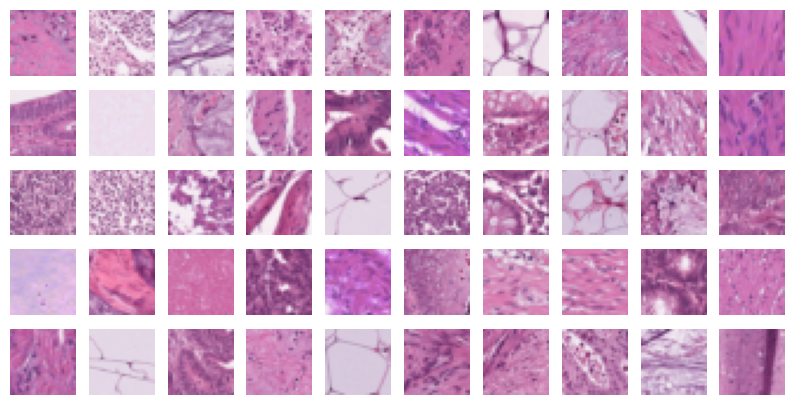

First 10 examples of y_train: [7 3 4 2 6 2 0 7 5 5]


In [12]:
# A function to show the examples in trainging dataset.

def examples_all(df, n_rows = 5, n_cols = 10):

    plt.figure(figsize=(n_cols, n_rows))
    plt.axis('off')

    for r in range(n_rows):
        for c in range(n_cols):

            index = r * 10 + c

            plt.subplot(n_rows, n_cols, index+1)
            plt.axis('off')
            plt.imshow(df[index], cmap= "binary" )

        
    plt.show()

examples_all(X_train_imshow)
print(f"First 10 examples of y_train: {y_train[0:10]}")


From the background knowledge, the PathMNIST is a medical image classification dataset derived from multiple tissue slice images.

The PathMNIST has 9 types of tissues as outputs

Let us check if the class in y is 0~8.

In [13]:
print(f"The class in y_train : {np.unique(y_train)}")
# The ans is yes.

The class in y_train : [0 1 2 3 4 5 6 7 8]


I would like to see some examples of different tissues.

The example figure of 'y = 0' type.


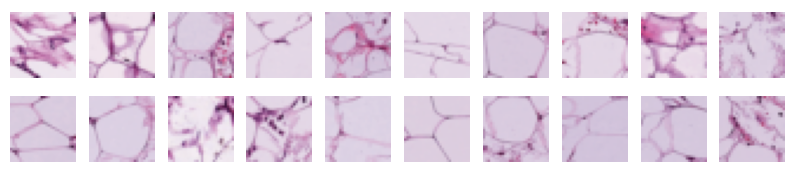

The example figure of 'y = 1' type.


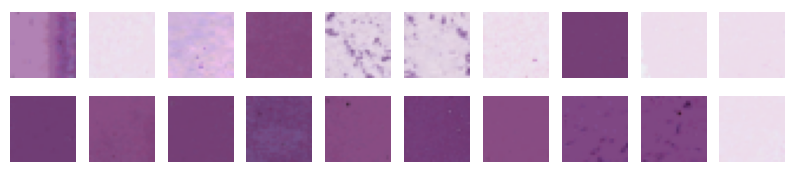

The example figure of 'y = 2' type.


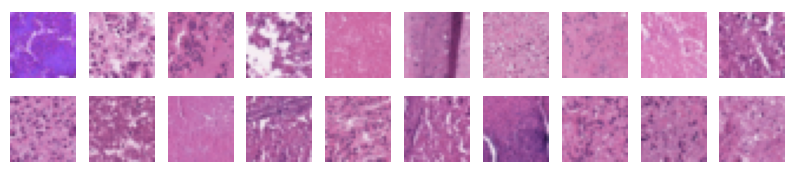

The example figure of 'y = 3' type.


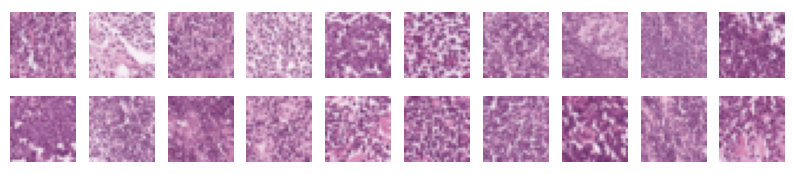

The example figure of 'y = 4' type.


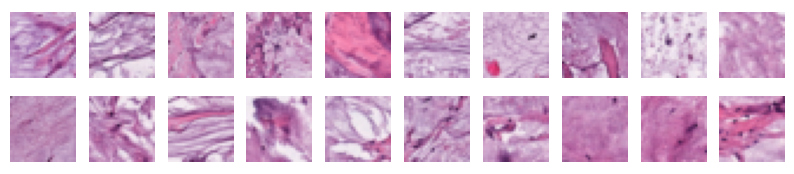

The example figure of 'y = 5' type.


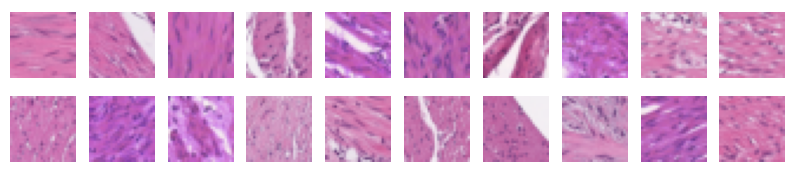

The example figure of 'y = 6' type.


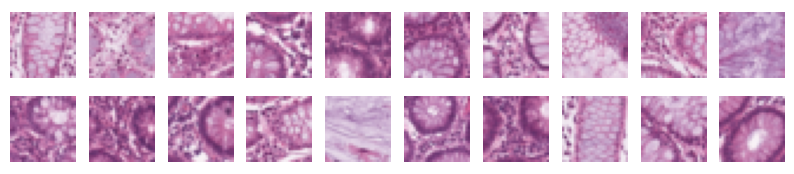

The example figure of 'y = 7' type.


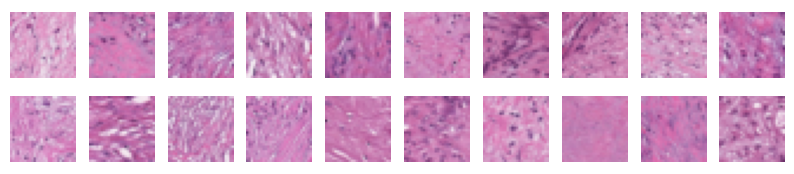

The example figure of 'y = 8' type.


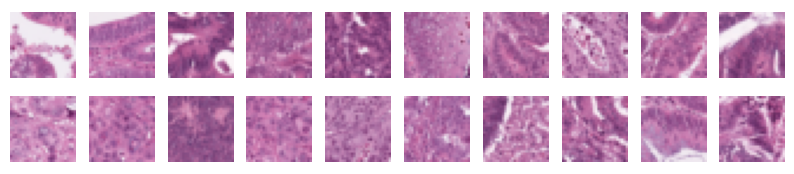

In [14]:
def example_single(y_value, n_cols = 10, n_rows = 2):

    plt.figure(figsize=(n_cols, n_rows))
    plt.axis('off')

    total = n_cols * n_rows
    i = 1
    
    index = 0
    index_list = []

    while i <= total:
        if y_train[index] == y_value:
            index_list.append(index)
            index += 1
            i += 1
        else:
            index += 1

    for r in range(n_rows):
        for c in range(n_cols):

            index = r * 10 + c

            plt.subplot(n_rows, n_cols, index+1)
            plt.axis('off')
            plt.imshow(X_train_imshow[index_list[index-1]], cmap= "binary" )
        
    plt.show()

def example_single_print():
    for i in range(9):
        print(f"The example figure of 'y = {i}' type.")
        example_single(i)

example_single_print()

Here I also want to see whether the tissue images of each type are evenly distributed in the training set and the test set.

In [15]:
# A function to check the percentage of tissue type.

def tissue_type_rate():

    train = Counter(y_train)
    test = Counter(y_test)
    y_unique = np.unique(y_train)

    res_train = pd.DataFrame()
    res_test = pd.DataFrame()

    for i in y_unique:
        df_train = pd.DataFrame([train[i],train[i]/32000]).T
        res_train = pd.concat([res_train, df_train])

        df_test = pd.DataFrame([test[i],test[i]/8000]).T
        res_test = pd.concat([res_test, df_test])
    
    res_train.index = (y_unique)
    res_train.columns = ['Quantity', 'Rate']

    res_test.index = (y_unique)
    res_test.columns = ['Quantity', 'Rate']

    print('y distubeted in training set:\n {}'.format(res_train))
    print('y distubeted in testing set:\n {}'.format(res_test))
        
tissue_type_rate()


y distubeted in training set:
    Quantity      Rate
0    3490.0  0.109063
1    3431.0  0.107219
2    3505.0  0.109531
3    3656.0  0.114250
4    2950.0  0.092188
5    4290.0  0.134063
6    2728.0  0.085250
7    3253.0  0.101656
8    4697.0  0.146781
y distubeted in testing set:
    Quantity      Rate
0     873.0  0.109125
1     858.0  0.107250
2     877.0  0.109625
3     914.0  0.114250
4     737.0  0.092125
5    1072.0  0.134000
6     682.0  0.085250
7     813.0  0.101625
8    1174.0  0.146750


So the types of y are evenly disbuted in training and testing set. Even through, there are still existed tiny difference between differnet tissues.
When reducing training size, I still need to follow the 'stratify = y'.

## 2. Algorithm design and setup

### Algorithm of choice from first six weeks of course

Normal machine learning model need two dimensions as input vector. So before input the data, we need to decrease the dimensions from four to two.

For some simple algorithm, they are not suit for the image regonition task. 

Here I only select two algorithm result to make sure they are not suitable.

In [16]:
# PCA method to decrease the deminsion.
def PCA_train(train, test):
    pca = PCA(n_components=0.95)  # Keep 95% information.

    pca_fit = pca.fit(train)

    res_train = pca_fit.transform(train)
    res_test = pca_fit.transform(test)
    print(f"After PCA method, remain dimensions:{res_train.shape[1]}")
    
    return res_train,res_test


In [17]:
flat_X_train_PCA,flat_X_test_PCA = PCA_train(flat_X_train,flat_X_test)

After PCA method, remain dimensions:343


In [18]:
# RandonForest algorithm setup.

def rf(n_estimators = 10, 
       max_leaf_nodes = 10,
       X_test = None,
       y_test = None
       ):
   
   start = time.time()

   rf = RandomForestClassifier(n_estimators = n_estimators, max_leaf_nodes = max_leaf_nodes,
                                criterion='entropy', max_features = 'sqrt', random_state=0)
   
   X_train_rf, X_valid_rf, y_train_rf, y_valid_rf = train_test_split(flat_X_train_PCA, y_train, train_size=0.9, random_state=0)

   if (X_test is None) and (y_test is None):
      X_test, y_test = X_valid_rf, y_valid_rf

   rf.fit(X_train_rf,y_train_rf)
   y_pred = rf.predict(X_test)

   end = time.time()

   Duration = round(end-start,3)
   acc_rf = round(accuracy_score(y_test, y_pred),3)
   f1_m = round(f1_score(y_test, y_pred, average='macro'),3)
   f1_w = round(f1_score(y_test, y_pred, average='weighted'),3)

   print("Rf Accuracy: {:.3f}".format(acc_rf))
   print("Rf Duration(s): {:.3f}".format(Duration))
   print("Rf F1 Macro: {:.3f}".format(f1_m))
   print("Rf F1 Weighted(s): {:.3f}".format(f1_w))

   return acc_rf,Duration,f1_m,f1_w


In [19]:
rf()

Rf Accuracy: 0.395
Rf Duration(s): 2.313
Rf F1 Macro: 0.296
Rf F1 Weighted(s): 0.310


(0.395, 2.313, 0.296, 0.31)

The RandomForest algorithm give out a accuracy with 42.9%.

Although it is not good enough, I still choose RandomForest to start tuning hyperparameter.

### Fully connected neural network

In [20]:
# Function to train MLP model.

def MLP(Dense_1 = 100, 
        Activation_1 = 'relu', 
        Dense_2 = 100, 
        Activation_2 = 'relu', 
        Learning_rate = 0.1,
        X_test = None,
        y_test = None
        ):
    # Ensure stability across runs
    keras.backend.clear_session()
    tf.random.set_seed(0)

    start = time.time()

    # Define our MLP layer by layer
    model = keras.models.Sequential([
        keras.layers.Input([28, 28, 3]),
        keras.layers.Flatten(),
        keras.layers.Dense(Dense_1, activation = Activation_1),
        keras.layers.Dense(Dense_2, activation = Activation_2),
        keras.layers.Dense(9, activation = "softmax")
        ])
    
    model.summary()

    # Instantiate optimiser and compile the model.
    opt = keras.optimizers.Adam(learning_rate=Learning_rate)
    model.compile(loss='sparse_categorical_crossentropy',
                optimizer=opt,
                metrics=['accuracy'])
    
    # Train the classifier.

    X_train_MLP, X_valid_MLP, y_train_MLP, y_valid_MLP = train_test_split(X_train, y_train, train_size=0.9, random_state=0)

    if (X_test is None) and (y_test is None):
        X_test, y_test = X_valid_MLP, y_valid_MLP

    history = model.fit(X_train_MLP, y_train_MLP, epochs=10, batch_size=128,
                        validation_data=(X_test, y_test))
    
    end = time.time()

    # Convert the history dictionary to a Pandas dataframe and extract the accuracies
    accuracies = pd.DataFrame(history.history)[['accuracy', 'val_accuracy']]
    losses = pd.DataFrame(history.history)[['loss', 'val_loss']]

    # Plot the accuracies
    accuracies.plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.xlabel('Epoch')
    plt.show()

    # Plot the losses
    losses.plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 5)
    plt.xlabel('Epoch')
    plt.show()

    # Predict
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1) # Label the output
    f1_m = round(f1_score(y_test, y_pred, average='macro'),3)

    acc_MLP = round(accuracies['val_accuracy'][9],3)
    loss_MLP = round(losses['val_loss'][9],3)
    Duration = round(end-start,3)

    print(f'MLP Final Accuracy :{acc_MLP}')
    print(f'MLP Duration(s) :{Duration}')
    print(f'MLP Final Loss :{loss_MLP}')
    print(f'MLP Final F1(Macro) :{f1_m}')


    return acc_MLP, Duration, loss_MLP, f1_m

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       235,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           909 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 246,309 (962.14 KB)

 Trainable params: 246,309 (962.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1376 - loss: 82.2460 - val_accuracy: 0.1441 - val_loss: 2.1857
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1410 - loss: 2.1910 - val_accuracy: 0.1094 - val_loss: 2.1875
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1406 - loss: 2.1887 - val_accuracy: 0.1094 - val_loss: 2.1881
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1409 - loss: 2.1891 - val_accuracy: 0.1094 - val_loss: 2.1885
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1404 - loss: 2.1894 - val_accuracy: 0.1094 - val_loss: 2.1886
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1401 - loss: 2.1895 - val_accuracy: 0.1094 - val_loss: 2.1887
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1401 - loss: 2.1897 - val_accuracy: 0.1094 - val_loss: 2.1888
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1391 - loss: 2.1898 - val_accuracy: 0

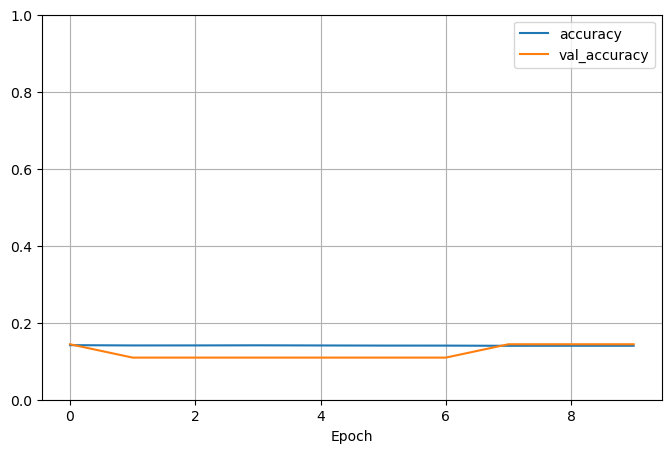

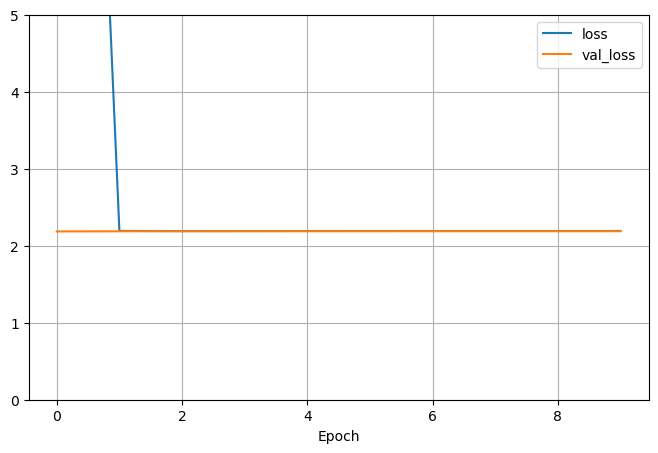

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step
MLP Final Accuracy :0.144
MLP Duration(s) :3.657
MLP Final Loss :2.189
MLP Final F1(Macro) :0.028


(0.144, 3.657, 2.189, 0.028)

In [21]:
MLP()

### Convolutional neural network

In [22]:
# Function to use Convolutional neural network.

def CNN(Activation_1 = 'relu', 
        Activation_2 = 'relu', 
        Dropout_rate = 0.2, 
        Learning_rate = 0.1, 
        X_test = None,
        y_test = None
        ):
    
    start = time.time()

    # Create validation set from the training set
    X_train_CNN, X_valid_CNN, y_train_CNN, y_valid_CNN = train_test_split(X_train, y_train, train_size=0.9, random_state=0)

    model = keras.Sequential([
    
    # Specify the input shape
    keras.Input(shape=(28, 28, 3)),

    # Conv and pool block 1
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation=Activation_1),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Conv and pool block 2
    keras.layers.Conv2D(64, kernel_size=(3, 3), activation=Activation_2),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Flatten and classify using dense output layer
    keras.layers.Flatten(),
    keras.layers.Dropout(Dropout_rate),
    keras.layers.Dense(9, activation="softmax"),
    ])

    model.summary()

    # Compile model with loss, optimiser, and metrics
    opt = keras.optimizers.Adam(learning_rate=Learning_rate)
    model.compile(loss='sparse_categorical_crossentropy',
                optimizer=opt,
                metrics=['accuracy'])
    
    if (X_test is None) and (y_test is None):
        X_test, y_test = X_valid_CNN, y_valid_CNN
    
    history = model.fit(X_train_CNN, y_train_CNN, batch_size=128,
                        epochs=10, validation_data=(X_test, y_test))
    
    end = time.time()
    Duration = round(end-start,3)
    
    # Convert the history dictionary to a Pandas dataframe and extract the accuracies
    accuracies = pd.DataFrame(history.history)[['accuracy', 'val_accuracy']]
    losses = pd.DataFrame(history.history)[['loss', 'val_loss']]

    # Plot the accuracies
    accuracies.plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.xlabel('Epoch')
    plt.show()

    # Plot the losses
    losses.plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 5)
    plt.xlabel('Epoch')
    plt.show()

    # Predict
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1) # Label the output
    f1_m = round(f1_score(y_test, y_pred, average='macro'),3)

    acc_CNN = round(accuracies['val_accuracy'][9],3)
    loss_CNN = round(losses['val_loss'][9],3)

    print(f'CNN Final Accuracy :{acc_CNN}')
    print(f'CNN Duration(s) :{Duration}')
    print(f'CNN Final loss :{loss_CNN}')
    print(f'CNN Final F1(Macro) :{f1_m}')

    return acc_CNN, Duration, loss_CNN, f1_m

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │        14,409 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,801 (132.04 KB)

 Trainable params: 33,801 (132.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1310 - loss: 29.1900 - val_accuracy: 0.1441 - val_loss: 2.1886
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1409 - loss: 2.1890 - val_accuracy: 0.1094 - val_loss: 2.1889
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1407 - loss: 2.1894 - val_accuracy: 0.1094 - val_loss: 2.1888
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1399 - loss: 2.1896 - val_accuracy: 0.1094 - val_loss: 2.1888
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1398 - loss: 2.1897 - val_accuracy: 0.1094 - val_loss: 2.1888
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1390 - loss: 2.1898 - val_accuracy: 0.1094 - val_loss: 2.1888
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1391 - loss: 2.1899 - val_accuracy: 0.1094 - val_loss: 2.1889
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1391 - loss: 2.1899 - val_acc

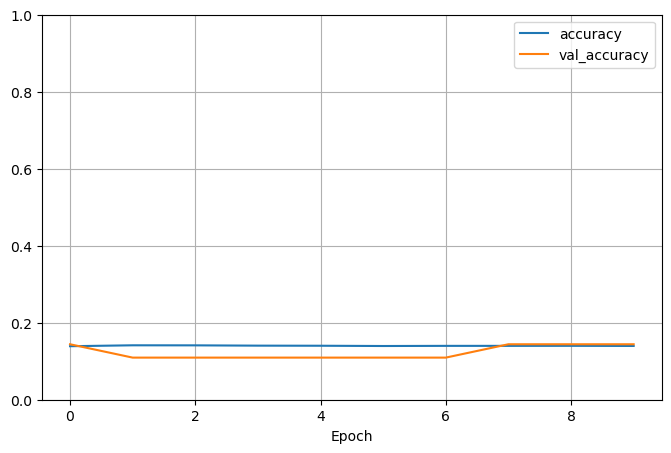

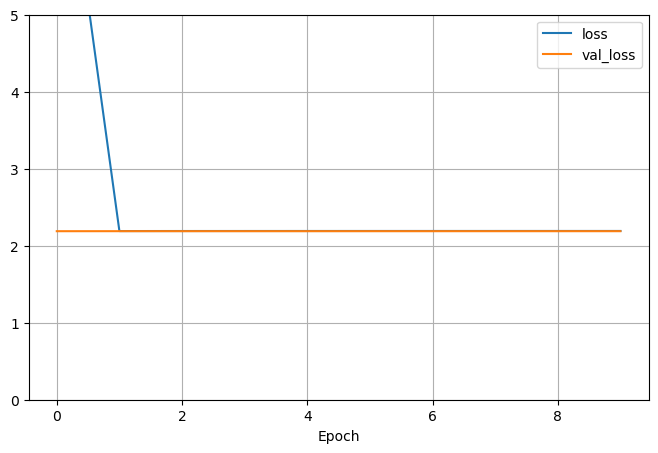

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CNN Final Accuracy :0.144
CNN Duration(s) :34.54
CNN Final loss :2.189
CNN Final F1(Macro) :0.028


(0.144, 34.54, 2.189, 0.028)

In [23]:
CNN()

## 3. Hyperparameter tuning

### Algorithm of choice from first six weeks of course

In [24]:
# RandomForest in hyperparamete tuning.

def bestRFClassifier():

    res = pd.DataFrame()

    n_estimators = [10, 20, 30]
    max_leaf_nodes = [10, 40, 70, 100]
    param_grid = {'n_estimators': n_estimators,
              'max_leaf_nodes': max_leaf_nodes}
    
    for paramater in ParameterGrid(param_grid):

        start = time.time() # Record the start time.
        rf = RandomForestClassifier(**paramater, criterion='entropy', max_features = 'sqrt', n_jobs = -1, random_state=0)
        scores = cross_val_score(rf, flat_X_train_PCA, y_train, cv=cvKFold, n_jobs=-1, scoring='accuracy')
        scores_f1_macro = cross_val_score(rf, flat_X_train_PCA, y_train, cv=cvKFold, n_jobs=-1, scoring='f1_macro')
        scores_f1_weighted = cross_val_score(rf, flat_X_train_PCA, y_train, cv=cvKFold, n_jobs = -1, scoring='f1_weighted')
        end = time.time() # Record the end time

        time_use = round(end - start, 3)
        accuracy_score = round(scores.mean(), 3) * 100
        f1_macro_score = round(scores_f1_macro.mean(), 3)
        f1_weighted_score = round(scores_f1_weighted.mean(), 3)

        df = pd.DataFrame([[time_use, 
                            accuracy_score, 
                            f1_macro_score, 
                            f1_weighted_score,
                            paramater['n_estimators'],
                            paramater['max_leaf_nodes']
                            ]])
        res = pd.concat([res,df])
    
    res.columns = ['Duration(s)', 
                   'Accuracy(%)', 
                   'F1(Macro)', 
                   'F1(Weighted)',
                   'n_estimators',
                   'max_leaf_nodes'
                   ]

    return res

In [25]:
df_Rf = bestRFClassifier()

In [26]:
df_Rf.sort_values('Accuracy(%)', ascending=False).head(20)

,Duration(s),Accuracy(%),F1(Macro),F1(Weighted),n_estimators,max_leaf_nodes
0,1002.598,58.3,0.518,0.535,30,100
0,98.297,57.0,0.501,0.518,30,70
0,73.708,56.6,0.502,0.518,20,100
0,64.206,55.4,0.482,0.500,20,70
0,80.390,54.9,0.463,0.482,30,40
0,40.086,54.7,0.487,0.503,10,100
0,32.795,53.6,0.471,0.487,10,70
0,53.643,52.9,0.442,0.461,20,40
0,27.818,51.7,0.437,0.456,10,40
0,46.855,44.0,0.335,0.355,30,10


So, consider the Accuracy and the duration.

We choose 'n_estimators = 10' and 'max_leaf_nodes = 100'.

### Fully connected neural network

In [27]:
# Re-write the Search method to catch the Running Duration.

class Time_GridSearch(keras_tuner.GridSearch):
    def run_trial(self, trial, *args, **kwargs):
        
        start = time.time()
        history = super().run_trial(trial, *args, **kwargs)
        end = time.time()

        duration = end-start
        trial.hyperparameters.values["Duration"] = duration # Here add a fake hyperparameters to store the duration
    
        return history

class Time_RandomSearch(keras_tuner.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        
        start = time.time()
        history = super().run_trial(trial, *args, **kwargs)
        end = time.time()

        duration = end-start
        trial.hyperparameters.values["Duration"] = duration # Here add a fake hyperparameters to store the duration
    
        return history

In [28]:
# Build the model for MLP. This is used for RandomResearch.
def build_model_MLP(hp):
    model = keras.models.Sequential()
    
    # Add the input layer
    model.add(keras.layers.Input(shape=[28,28,3]))
    model.add(keras.layers.Flatten())
    

    # Add 2 hidden layers, treating the number of hidden neurons 
    # and the activation function in each as hyperparameters to tune over
    for i in range(1, 3):
        model.add(
            keras.layers.Dense(
                units=hp.Choice(f"Dense {i}", values=[100, 200]),
                activation=hp.Choice(f"Activation {i}", values=["relu", "sigmoid", "tanh"])
            )
        )

    # Add the output layer for 9 class classification
    model.add(keras.layers.Dense(9, activation="softmax"))

    # Set up the learning rate values to be tuned over and define the model
    learning_rate = hp.Choice('Learning_rate', values=[0.1, 0.01, 0.001])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [29]:
# MLP in hyperparamete tuning. Here we have the 108 trials, we select 30 random trials.

def RandomMLPClassifier():

    tuner = Time_RandomSearch(
        hypermodel=build_model_MLP,
        objective="val_accuracy",
        max_trials=30,
        executions_per_trial=1,
        overwrite=True,
        directory="keras_tuning_results",
        seed = 0
        )

    X_train_MLP, X_valid_MLP, y_train_MLP, y_valid_MLP = train_test_split(X_train, y_train, train_size=0.9, random_state=0)

    tuner.search(X_train_MLP, y_train_MLP, epochs=10, validation_data=(X_valid_MLP, y_valid_MLP))

    res = pd.DataFrame()

    for trial in tuner.oracle.trials.values():

        df = pd.DataFrame([round(trial.score,3) * 100,
                            round(trial.hyperparameters.values['Duration'],3),
                            trial.hyperparameters.values['Dense 1'],
                            trial.hyperparameters.values['Activation 1'],
                            trial.hyperparameters.values['Dense 2'],
                            trial.hyperparameters.values['Activation 2'],
                            trial.hyperparameters.values['Learning_rate']
                           ]).T
        df.index = [str(int(trial.trial_id)+1)]
        
        res = pd.concat([res,df])

    res.columns = (['Accuracy(%)', 'Duration(s)', 'Dense 1', 'Activation 1', 'Dense 2', 'Activation 2', 'Learning rate'])

    return res

In [30]:
df_MLP_Random = RandomMLPClassifier()

Trial 30 Complete [00h 00m 18s]
val_accuracy: 0.14406250417232513

Best val_accuracy So Far: 0.6384375095367432
Total elapsed time: 00h 07m 34s


In [31]:
df_MLP_Random.sort_values('Accuracy(%)', ascending=False).head(20)

,Accuracy(%),Duration(s),Dense 1,Activation 1,Dense 2,Activation 2,Learning rate
12,63.8,11.77,100,relu,200,relu,0.001
25,63.5,16.474,200,relu,100,sigmoid,0.001
24,62.5,17.318,200,relu,200,relu,0.001
1,61.5,14.56,200,relu,100,relu,0.001
4,60.6,15.013,200,sigmoid,100,relu,0.001
10,60.5,17.064,200,sigmoid,100,tanh,0.001
18,59.8,17.662,200,tanh,100,tanh,0.001
26,59.4,11.436,100,tanh,200,relu,0.001
21,59.0,11.718,100,tanh,100,sigmoid,0.001
14,58.6,17.283,200,tanh,100,sigmoid,0.001


Here we fix the hyperparameter 'learning rate = 0.001'.
Do GridResearch to the remain hyperparameter.

In [32]:
# Build the model for MLP.
def build_model_MLP_2(hp):
    model = keras.models.Sequential()
    
    # Add the input layer
    model.add(keras.layers.Input(shape=[28,28,3]))
    model.add(keras.layers.Flatten())
    

    # Add 2 hidden layers, treating the number of hidden neurons 
    # and the activation function in each as hyperparameters to tune over
    for i in range(1, 3):
        model.add(
            keras.layers.Dense(
                units=hp.Choice(f"Dense {i}", values=[100, 200]),
                activation=hp.Choice(f"Activation {i}", values=["relu", "sigmoid", "tanh"])
            )
        )

    # Add the output layer for 9 class classification
    model.add(keras.layers.Dense(9, activation="softmax"))

    # Set up the learning rate values to be tuned over and define the model
    learning_rate = 0.001
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [33]:
# MLP in hyperparamete tuning. Here we have the 36 trials.

def GridMLPClassifier():

    tuner = Time_GridSearch(
        hypermodel=build_model_MLP_2,
        objective="val_accuracy",
        max_trials=None,
        executions_per_trial=1,
        overwrite=True,
        directory="keras_tuning_results",
        seed = 0
        )

    X_train_MLP, X_valid_MLP, y_train_MLP, y_valid_MLP = train_test_split(X_train, y_train, train_size=0.9, random_state=0)

    tuner.search(X_train_MLP, y_train_MLP, epochs=10, validation_data=(X_valid_MLP, y_valid_MLP))

    res = pd.DataFrame()

    for trial in tuner.oracle.trials.values():

        df = pd.DataFrame([round(trial.score,3) * 100,
                            round(trial.hyperparameters.values['Duration'],3),
                            trial.hyperparameters.values['Dense 1'],
                            trial.hyperparameters.values['Activation 1'],
                            trial.hyperparameters.values['Dense 2'],
                            trial.hyperparameters.values['Activation 2']
                           ]).T
        df.index = [str(int(trial.trial_id)+1)]
        
        res = pd.concat([res,df])

    res.columns = (['Accuracy(%)', 'Duration(s)', 'Dense 1', 'Activation 1', 'Dense 2', 'Activation 2'])

    return res

In [34]:
df_MLP_Grid = GridMLPClassifier()

Trial 36 Complete [00h 00m 18s]
val_accuracy: 0.5975000262260437

Best val_accuracy So Far: 0.645312488079071
Total elapsed time: 00h 08m 24s


In [35]:
df_MLP_Grid.sort_values('Accuracy(%)', ascending=False).head(20)

,Accuracy(%),Duration(s),Dense 1,Activation 1,Dense 2,Activation 2
23,64.5,16.828,200,relu,200,sigmoid
22,64.2,15.723,200,relu,200,relu
20,63.9,15.772,200,relu,100,sigmoid
2,63.8,11.767,100,relu,100,sigmoid
5,63.8,12.297,100,relu,200,sigmoid
6,63.3,12.927,100,relu,200,tanh
1,63.1,11.801,100,relu,100,relu
4,63.0,11.508,100,relu,200,relu
19,62.9,17.138,200,relu,100,relu
3,62.2,11.411,100,relu,100,tanh


So, consider the Accuracy and the duration.

We choose 'Dense 1 = 100', 'Activation 1 = 'relu'', 'Dense 2 = 200', 'Activation 1 = 'tanh'', 'learning rate = 0.001'.

### Convolutional neural network

In [36]:
# Build the model for CNN. 
def build_model_CNN(hp):
    model = keras.models.Sequential()
    
    # Add the input layer
    model.add(keras.layers.Input(shape=[28,28,3]))

    # Add 2 hidden layers, treating the number of hidden neurons 
    # and the activation function in each as hyperparameters to tune over

    
    model.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation=hp.Choice(f"Activation {1}", values=["relu", "sigmoid", "tanh"])),
              keras.layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(keras.layers.Conv2D(64, kernel_size=(3, 3), activation=hp.Choice(f"Activation {2}", values=["relu", "sigmoid", "tanh"])),
              keras.layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(keras.layers.Flatten())
    Dropout_rate = hp.Choice('Dropout_rate', values=[0.2, 0.5, 0.8])
    model.add(keras.layers.Dropout(Dropout_rate))

    # Add the output layer for 9 class classification
    model.add(keras.layers.Dense(9, activation="softmax"))

    # Set up the learning rate values to be tuned over and define the model
    learning_rate = hp.Choice('Learning_rate', values=[0.1, 0.01, 0.001])
    opt = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='sparse_categorical_crossentropy',
                optimizer=opt,
                metrics=['accuracy'])
    
    return model

In [37]:
# CNN in hyperparamete tuning. Here we have 81 trials, we choose random 20 trials.

def RandomCNNClassifier():
    
    tuner = Time_RandomSearch(
        hypermodel=build_model_CNN,
        objective="val_accuracy",
        max_trials=20,
        executions_per_trial=1,
        overwrite=True,
        directory="keras_tuning_results",
        seed = 0
        )

    X_train_MLP, X_valid_MLP, y_train_MLP, y_valid_MLP = train_test_split(X_train, y_train, train_size=0.9, random_state=0)

    tuner.search(X_train_MLP, y_train_MLP, batch_size = 128, epochs=10, validation_data=(X_valid_MLP, y_valid_MLP))

    res = pd.DataFrame()

    for trial in tuner.oracle.trials.values():

        df = pd.DataFrame([round(trial.score,3)*100,
                            round(trial.hyperparameters.values['Duration'],3),
                            trial.hyperparameters.values['Activation 1'],
                            trial.hyperparameters.values['Activation 2'],
                            trial.hyperparameters.values['Dropout_rate'],
                            trial.hyperparameters.values['Learning_rate'],
                           ]).T
        df.index = [str(int(trial.trial_id)+1)]
        
        res = pd.concat([res,df])

    res.columns = (['Accuracy(%)', 'Duration(s)', 'Activation 1', 'Activation 2', 'Dropout rate', 'Learning rate'])

    return res

In [38]:
df_CNN_Random = RandomCNNClassifier()

Trial 20 Complete [00h 02m 20s]
val_accuracy: 0.7240625023841858

Best val_accuracy So Far: 0.8303124904632568
Total elapsed time: 00h 45m 23s


In [39]:
df_CNN_Random.sort_values('Accuracy(%)', ascending=False).head(20)

,Accuracy(%),Duration(s),Activation 1,Activation 2,Dropout rate,Learning rate
17,83.0,135.613,relu,relu,0.5,0.001
19,78.1,136.884,relu,tanh,0.8,0.001
12,77.2,135.982,tanh,relu,0.2,0.001
1,76.8,134.683,relu,sigmoid,0.5,0.001
18,76.8,136.784,relu,tanh,0.8,0.001
16,73.5,140.827,tanh,sigmoid,0.5,0.001
20,72.4,140.0,tanh,sigmoid,0.2,0.001
15,69.3,139.485,tanh,sigmoid,0.2,0.01
11,67.8,135.633,relu,tanh,0.2,0.01
9,67.5,139.257,sigmoid,sigmoid,0.5,0.001


Here we fix the hyperparameter 'learning rate = 0.001' and 'activation 1 = relu'. Do GridResearch to the remain hyperparameter.

In [40]:
def build_model_CNN_2(hp):
    model = keras.models.Sequential()
    
    # Add the input layer
    model.add(keras.layers.Input(shape=[28,28,3]))

    # Add 2 hidden layers, treating the number of hidden neurons 
    # and the activation function in each as hyperparameters to tune over
    model.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),keras.layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(keras.layers.Conv2D(64, kernel_size=(3, 3), activation=hp.Choice(f"Activation {2}", values=["relu", "sigmoid", "tanh"])),
              keras.layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(keras.layers.Flatten())
    Dropout_rate = hp.Choice('Dropout_rate', values=[0.2, 0.5, 0.8])
    model.add(keras.layers.Dropout(Dropout_rate))

    # Add the output layer for 9 class classification
    model.add(keras.layers.Dense(9, activation="softmax"))

    # Set up the learning rate values to be tuned over and define the model
    learning_rate = 0.001
    opt = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='sparse_categorical_crossentropy',
                optimizer=opt,
                metrics=['accuracy'])
    
    return model

In [41]:
# CNN in hyperparamete tuning. Here we have grid search.

def GridCNNClassifier():
    
    tuner = Time_GridSearch(
        hypermodel=build_model_CNN_2,
        objective="val_accuracy",
        max_trials=None,
        executions_per_trial=1,
        overwrite=True,
        directory="keras_tuning_results",
        seed = 0
        )

    X_train_MLP, X_valid_MLP, y_train_MLP, y_valid_MLP = train_test_split(X_train, y_train, train_size=0.9, random_state=0)

    tuner.search(X_train_MLP, y_train_MLP, batch_size = 128, epochs=10, validation_data=(X_valid_MLP, y_valid_MLP))

    res = pd.DataFrame()

    for trial in tuner.oracle.trials.values():

        df = pd.DataFrame([round(trial.score,3)*100,
                            round(trial.hyperparameters.values['Duration'],3),
                            trial.hyperparameters.values['Activation 2'],
                            trial.hyperparameters.values['Dropout_rate']
                           ]).T
        df.index = [str(int(trial.trial_id)+1)]
        
        res = pd.concat([res,df])

    res.columns = (['Accuracy(%)', 'Duration(s)', 'Activation 2', 'Dropout rate'])

    return res

In [42]:
df_CNN_Grid = GridCNNClassifier()

Trial 9 Complete [00h 02m 15s]
val_accuracy: 0.7740625143051147

Best val_accuracy So Far: 0.8471875190734863
Total elapsed time: 00h 20m 30s


In [43]:
df_CNN_Grid.sort_values('Accuracy(%)', ascending=False).head(20)

,Accuracy(%),Duration(s),Activation 2,Dropout rate
3,84.7,135.127,relu,0.8
2,82.0,135.212,relu,0.5
1,80.1,135.619,relu,0.2
4,78.2,139.051,sigmoid,0.2
6,77.5,138.22,sigmoid,0.8
5,77.4,138.787,sigmoid,0.5
9,77.4,134.78,tanh,0.8
8,74.4,136.404,tanh,0.5
7,71.4,137.07,tanh,0.2


So, consider the Accuracy and the duration.

We choose 'Activation 1 = 'relu'', 'Activation 2 = 'relu'', 'Dropout rate = 0.8', 'learning rate = 0.001'.

In [44]:
# Store the data to the csv document.
df_Rf.sort_values('Accuracy(%)', ascending=False, inplace=True)
df_MLP_Random.sort_values('Accuracy(%)', ascending=False, inplace = True)
df_MLP_Grid.sort_values('Accuracy(%)', ascending=False, inplace=True)
df_CNN_Random.sort_values('Accuracy(%)', ascending=False, inplace=True)
df_CNN_Grid.sort_values('Accuracy(%)', ascending=False, inplace=True)
df_Rf.to_csv(f'RF_{datetime.now()}.csv')
df_MLP_Random.to_csv(f'MLP_R{datetime.now()}.csv')
df_MLP_Grid.to_csv(f'MLP_G{datetime.now()}.csv')
df_CNN_Random.to_csv(f'CNN_R{datetime.now()}.csv')
df_CNN_Grid.to_csv(f'CNN_G{datetime.now()}.csv')

## 4. Final models

### Algorithm of choice from first six weeks of course

For Random Forest model, we use hyperparameter list:

n_estimators = 10

max_leaf_nodes = 100

In [45]:
acc_rf, Duration_rf, f1_m_rf, f1_w_rf = rf(n_estimators = 10, 
    max_leaf_nodes = 100,
    X_test = flat_X_test_PCA,
    y_test = y_test
    )

Rf Accuracy: 0.546
Rf Duration(s): 4.686
Rf F1 Macro: 0.489
Rf F1 Weighted(s): 0.504


### Fully connected neural network

For MLP model, we use hyperparameter list:

Dense_1 = 100

Activation_1 = 'relu'

Dense_2 = 200

Activation_2 = 'tanh'

Learning_rate = 0.001,

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       235,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,809 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,309 (1005.11 KB)

 Trainable params: 257,309 (1005.11 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4930 - loss: 1.3757 - val_accuracy: 0.6143 - val_loss: 1.0152
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6316 - loss: 0.9640 - val_accuracy: 0.6254 - val_loss: 0.9806
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6854 - loss: 0.8412 - val_accuracy: 0.6301 - val_loss: 0.9872
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7228 - loss: 0.7558 - val_accuracy: 0.6225 - val_loss: 1.0058
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7570 - loss: 0.6802 - val_accuracy: 0.6196 - val_loss: 1.0298
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7880 - loss: 0.6119 - val_accuracy: 0.6161 - val_loss: 1.0655
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8125 - loss: 0.5514 - val_accuracy: 0.6184 - val_loss: 1.0941
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8325 - loss: 0.5019 - val_accuracy: 0.

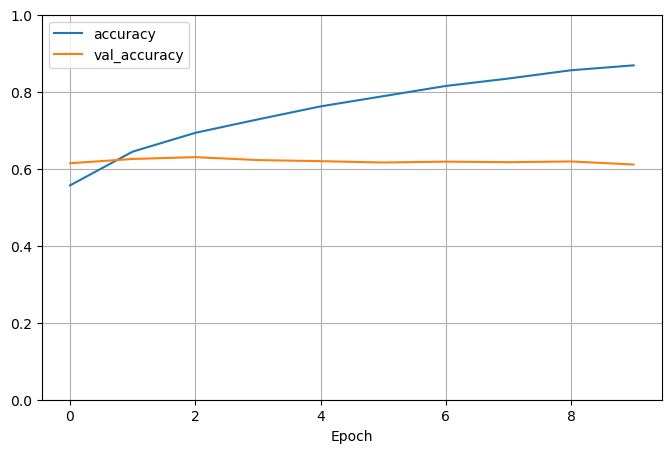

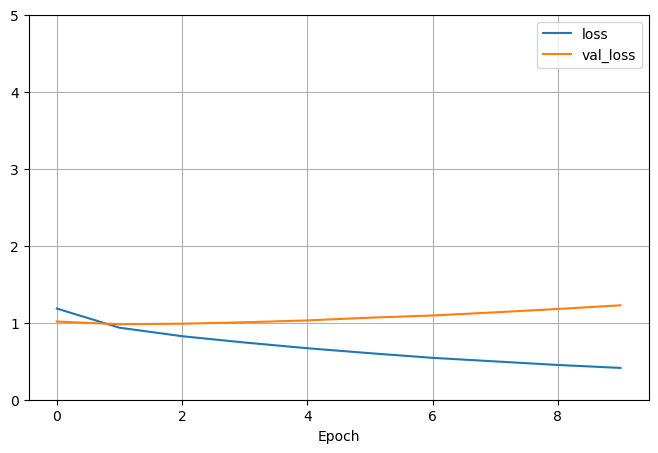

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step
MLP Final Accuracy :0.611
MLP Duration(s) :6.959
MLP Final Loss :1.226
MLP Final F1(Macro) :0.587


In [46]:
acc_MLP,Duration_MLP,loss_MLP,f1_m_MLP = MLP(Dense_1 = 100, 
        Activation_1 = 'relu', 
        Dense_2 = 200, 
        Activation_2 = 'tanh', 
        Learning_rate = 0.001,
        X_test = X_test,
        y_test = y_test
        )

### Convolutional neural network

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │        14,409 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,801 (132.04 KB)

 Trainable params: 33,801 (132.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4093 - loss: 1.5954 - val_accuracy: 0.6587 - val_loss: 0.9269
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6350 - loss: 0.9679 - val_accuracy: 0.7124 - val_loss: 0.7809
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6977 - loss: 0.8186 - val_accuracy: 0.7661 - val_loss: 0.6689
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7393 - loss: 0.7228 - val_accuracy: 0.7933 - val_loss: 0.6016
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7633 - loss: 0.6620 - val_accuracy: 0.8075 - val_loss: 0.5490
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7834 - loss: 0.6113 - val_accuracy: 0.8259 - val_loss: 0.5049
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7899 - loss: 0.5835 - val_accuracy: 0.8296 - val_loss: 0.4809
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8030 - loss: 0.5554 - val_accu

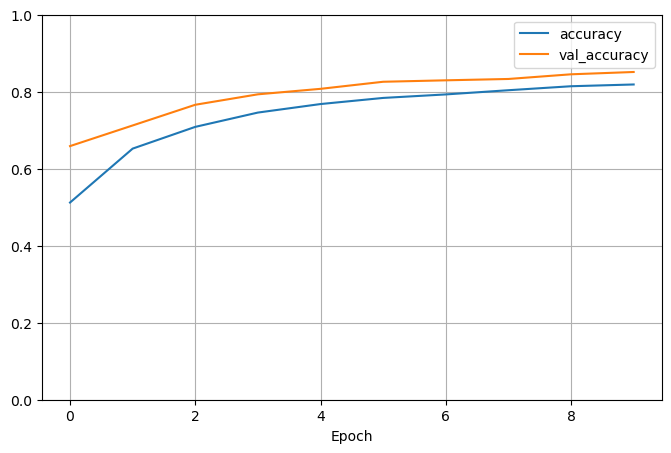

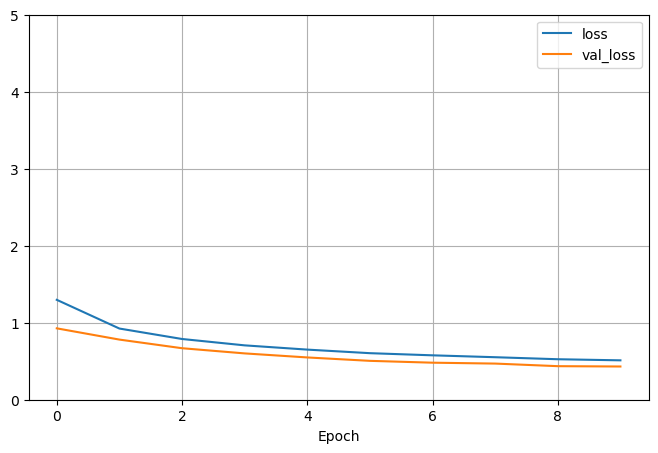

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN Final Accuracy :0.851
CNN Duration(s) :44.719
CNN Final loss :0.431
CNN Final F1(Macro) :0.844


In [47]:
acc_CNN,Duration_CNN,loss_CNN,f1_m_CNN = CNN(Activation_1 = 'relu', 
        Activation_2 = 'relu', 
        Dropout_rate = 0.8, 
        Learning_rate = 0.001, 
        X_test = X_test,
        y_test = y_test
        )

The final result is shown:

In [48]:
print(f'Final RandomForest Accuracy on test set: {acc_rf}')
print(f'Final RandomForest Duration on test set: {Duration_rf}')
print(f'Final RandomForest F1(Macro) on test set: {f1_m_rf}')
print(f'Final RandomForest F1(Weighted) on test set: {f1_w_rf}')
print()
print(f'Final MLP Accuracy on test set: {acc_MLP}')
print(f'Final MLP Duration on test set: {Duration_MLP}')
print(f'Final MLP Loss on test set: {loss_MLP}')
print(f'Final MLP F1(Macro) on test set: {f1_m_MLP}')
print()
print(f'Final CNN Accuracy on test set: {acc_CNN}')
print(f'Final CNN Duration on test set: {Duration_CNN}')
print(f'Final CNN Loss on test set: {loss_CNN}')
print(f'Final CNN F1(Macro) on test set: {f1_m_CNN}')

Final RandomForest Accuracy on test set: 0.546
Final RandomForest Duration on test set: 4.686
Final RandomForest F1(Macro) on test set: 0.489
Final RandomForest F1(Weighted) on test set: 0.504

Final MLP Accuracy on test set: 0.611
Final MLP Duration on test set: 6.959
Final MLP Loss on test set: 1.226
Final MLP F1(Macro) on test set: 0.587

Final CNN Accuracy on test set: 0.851
Final CNN Duration on test set: 44.719
Final CNN Loss on test set: 0.431
Final CNN F1(Macro) on test set: 0.844
